In [8]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nadaahmedsamir_heart_disease_uni_dataset_path = kagglehub.dataset_download('nadaahmedsamir/heart-disease-uni-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'heart-disease-uni-dataset' dataset.
Data source import complete.


# Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Load Data

In [10]:
import os

train_df=pd.read_csv(os.path.join(nadaahmedsamir_heart_disease_uni_dataset_path, "train_data.csv"))
test_df=pd.read_csv(os.path.join(nadaahmedsamir_heart_disease_uni_dataset_path, "test_data.csv"))

# Data Overview

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       224 non-null    int64  
 1   Age                      220 non-null    float64
 2   Gender                   218 non-null    object 
 3   Chest pain type          224 non-null    int64  
 4   BP                       224 non-null    int64  
 5   Cholesterol              224 non-null    int64  
 6   FBS over 120             224 non-null    int64  
 7   EKG results              224 non-null    int64  
 8   Max HR                   224 non-null    int64  
 9   Exercise angina          224 non-null    int64  
 10  ST depression            224 non-null    float64
 11  Slope of ST              224 non-null    int64  
 12  Number of vessels fluro  224 non-null    int64  
 13  Thallium                 224 non-null    int64  
 14  work_type                2

In [12]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

data_info(train_df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[134, 133, 132, 131, 130, 129, 128, 136, 135, 10]",215,0,0.000000,9
1,Age,float64,"[54.0, 58.0, 57.0, 59.0, 60.0, 42.0, 51.0, 64....",41,4,1.785714,9
2,Gender,object,"[Female, Male]",2,6,2.678571,9
3,Chest pain type,int64,"[4, 3, 2, 1]",4,0,0.000000,9
4,BP,int64,"[120, 140, 130, 110, 150, 125, 112, 160, 128, ...",45,0,0.000000,9
5,Cholesterol,int64,"[269, 234, 226, 211, 177, 230, 197, 246, 233, ...",122,0,0.000000,9
6,FBS over 120,int64,"[0, 1]",2,0,0.000000,9
7,EKG results,int64,"[2, 0, 1]",3,0,0.000000,9
8,Max HR,int64,"[160, 163, 125, 162, 165, 178, 169, 152, 173, ...",81,0,0.000000,9
9,Exercise angina,int64,"[0, 1]",2,0,0.000000,9


In [13]:
train_df.head()

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


# Analysis and Visualizations to get Information about the data

<BarContainer object of 2 artists>

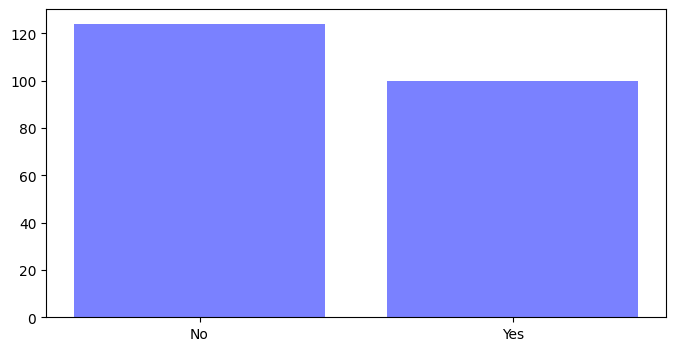

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(train_df["Heart Disease"].value_counts().index, train_df["Heart Disease"].value_counts().values, color="#7A81FF")

No class imbalance

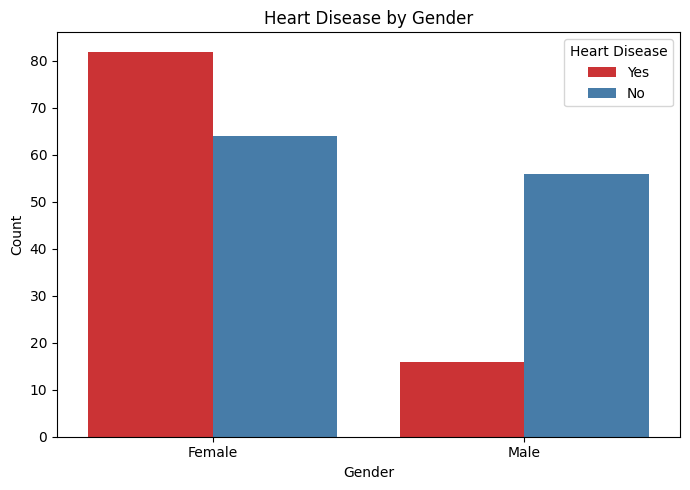

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Gender', hue='Heart Disease', palette='Set1')
plt.title('Heart Disease by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

- Most females have heart disease while most males don't

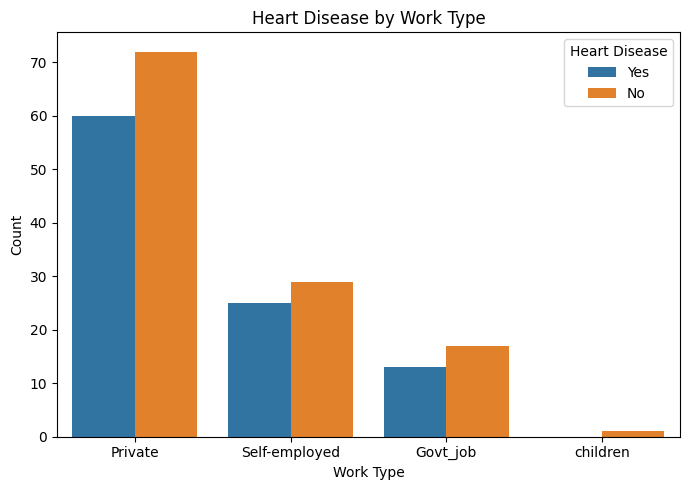

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='work_type', hue='Heart Disease')
plt.title('Heart Disease by Work Type')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

- the most value of who have heart disease is with people who works in the private sector
- the least value of who have heart disease is with children
- overall, most people are working in the private sector

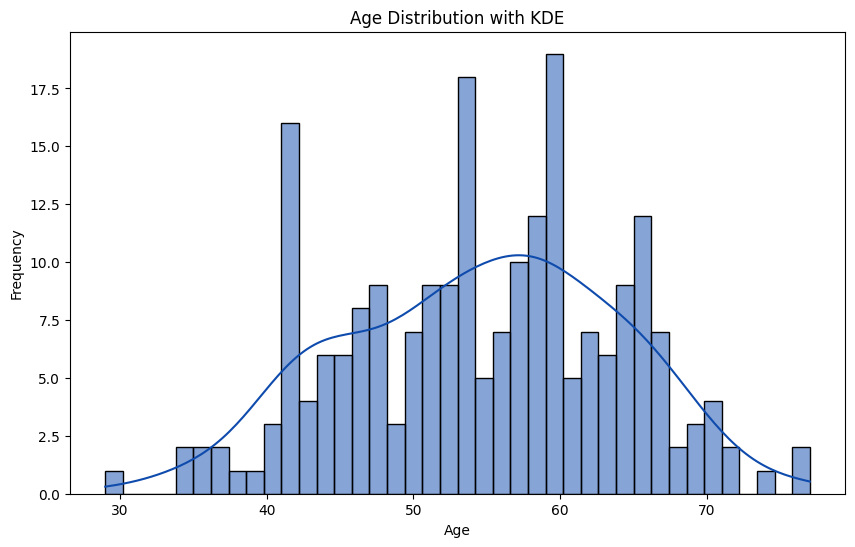

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['Age'], kde=True, color="#0E4BAD", edgecolor='black', bins=40)
plt.title('Age Distribution with KDE')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Near to Normal distribution

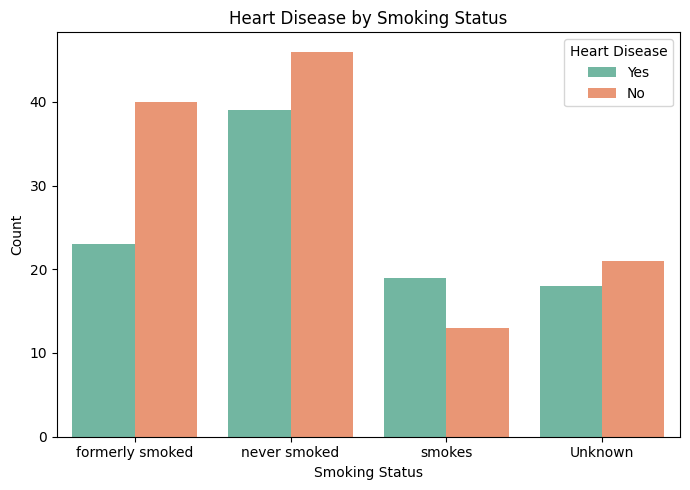

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='smoking_status', hue='Heart Disease', palette='Set2')
plt.title('Heart Disease by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

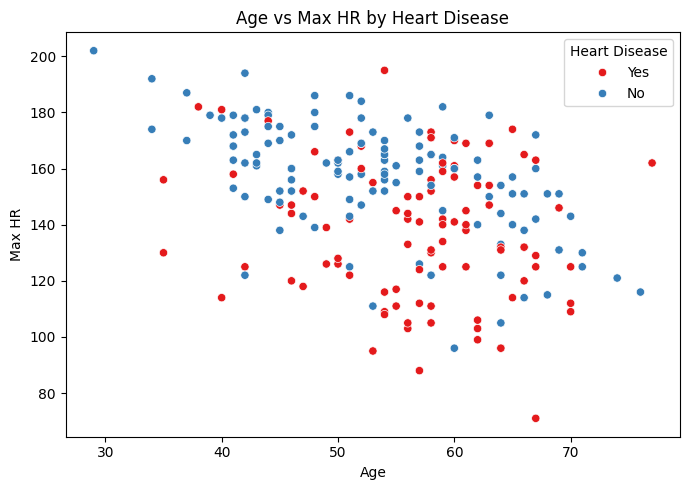

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=train_df, x='Age', y='Max HR', hue='Heart Disease', palette='Set1')
plt.title('Age vs Max HR by Heart Disease')
plt.tight_layout()
plt.show()

- people between 55 : 70 mostly have heart disease
- people between 30 : 55 mostly doesn't have heart disease

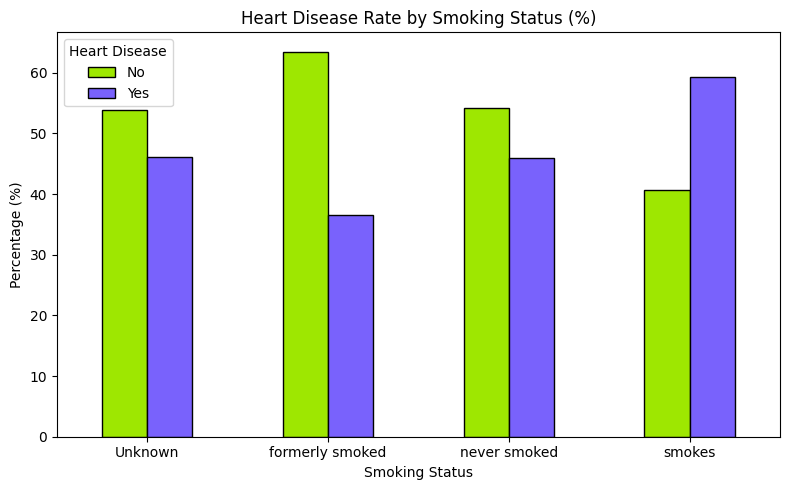

In [20]:
ct = pd.crosstab(train_df['smoking_status'], train_df['Heart Disease'], normalize='index') * 100
ct.plot(kind='bar', figsize=(8, 5), color=["#9ee701","#7962fc"], edgecolor='black')
plt.title('Heart Disease Rate by Smoking Status (%)')
plt.xlabel('Smoking Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

- the greatest percentage of who don't have heart disease is who formely smoked
- the greatest percentage of who have heart disease is who smokes
- the least percentage of who has heart disease is who formely smoked
- the least percentage of who doesn't have heart disease is who smokes

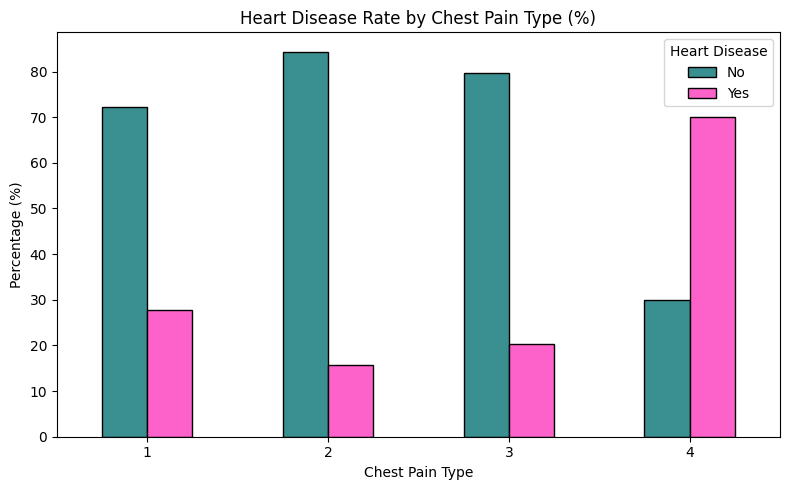

In [21]:
ct = pd.crosstab(train_df['Chest pain type'], train_df['Heart Disease'], normalize='index') * 100
ct.plot(kind='bar', figsize=(8, 5), color=["#3a8f91","#fc62c9"], edgecolor='black')
plt.title('Heart Disease Rate by Chest Pain Type (%)')
plt.xlabel('Chest Pain Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

- most percentage of who has heart disease also suffer from 4th pain type
- most percentage of who doesn't have heart disease also suffer from 2nd pain type
- least percentage of who has heart disease also suffer from 2nd pain type
- least percentage of who doesn't have heart disease also suffer from 4th pain type

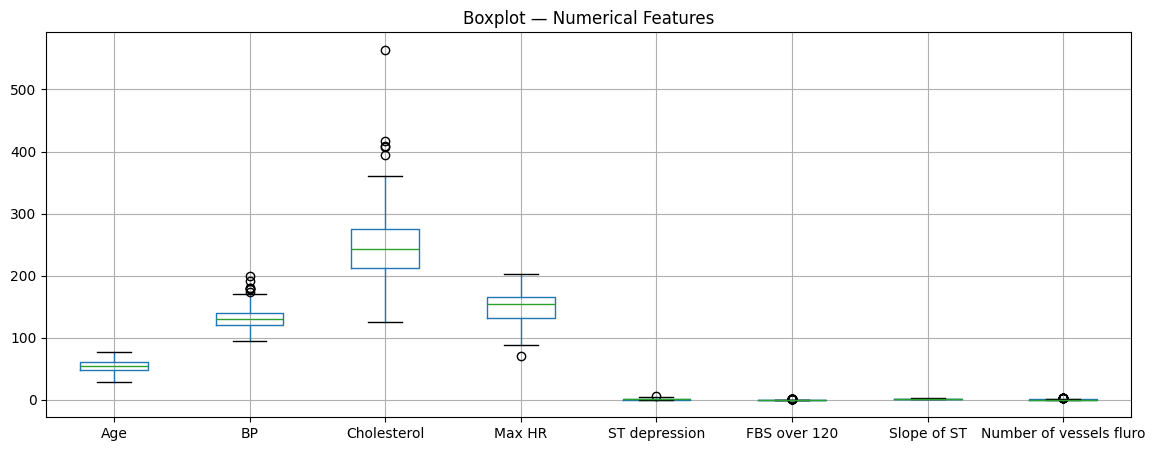

In [22]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression',
                  'FBS over 120', 'Slope of ST',
                  'Number of vessels fluro']

train_df[numerical_cols].boxplot(figsize=(14, 5))
plt.title("Boxplot — Numerical Features")
plt.show()

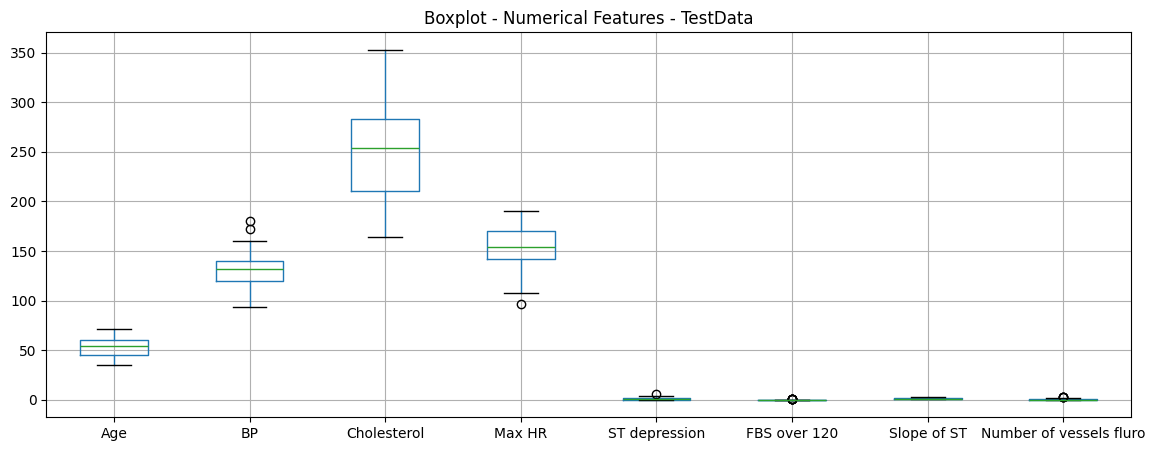

In [23]:
test_df[numerical_cols].boxplot(figsize=(14, 5))
plt.title("Boxplot - Numerical Features - TestData")
plt.show()

- Data has not to much outliers
- Will not drop/clip all outliers as that will affect the data, because of its li,ited size
- So only BP and Cholestrol outliers will be clipped
- Others don't have too much outliers and they won't badly affect the data overall

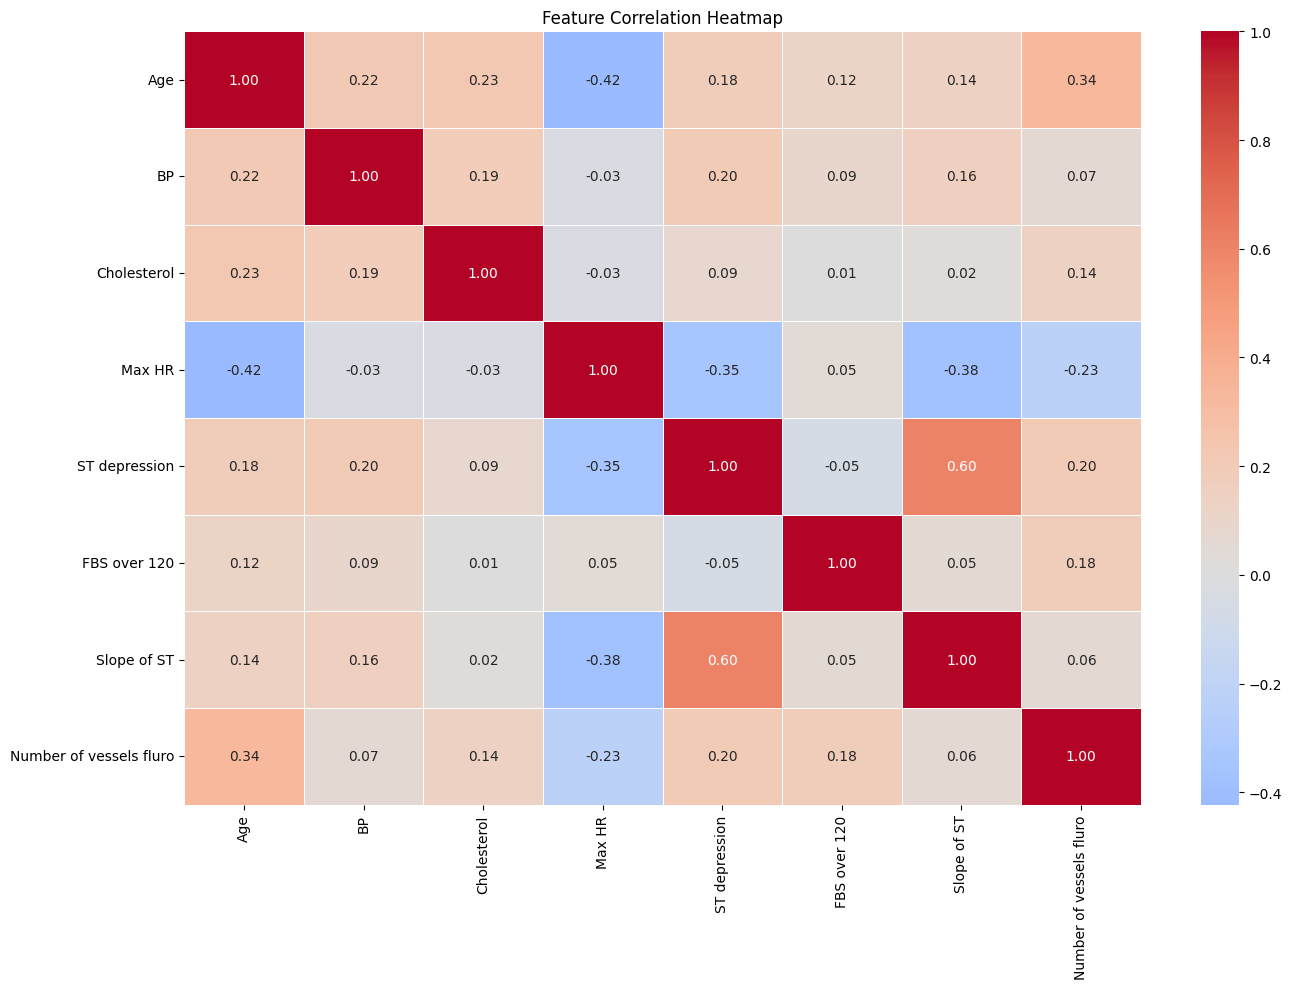

In [24]:

plt.figure(figsize=(14, 10))
correlation = train_df[numerical_cols].corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Preprocessing (Nulls, Duplicates, Outliers)

In [25]:
train_df.drop(columns=['id'],inplace=True)
test_df.drop(columns=['id'],inplace=True)

In [26]:
train_df.duplicated().sum()

np.int64(9)

In [27]:
test_df.duplicated().sum()

np.int64(1)

In [28]:
train_df.drop_duplicates()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,59.0,Female,1,170,288,0,2,159,0,0.2,2,0,7,Private,never smoked,Yes
220,51.0,Female,3,125,245,1,2,166,0,2.4,2,0,3,NaN,formerly smoked,No
221,43.0,Male,3,122,213,0,0,165,0,0.2,2,0,3,Private,never smoked,No
222,58.0,Female,4,128,216,0,2,131,1,2.2,2,3,7,Private,never smoked,Yes


In [29]:
test_df.drop_duplicates()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No
5,54.0,Female,4,110,239,0,0,126,1,2.8,2,1,7,Private,smokes,Yes
6,65.0,Female,4,135,254,0,2,127,0,2.8,2,1,7,Private,never smoked,Yes
7,57.0,Female,3,150,168,0,0,174,0,1.6,1,0,3,Govt_job,formerly smoked,No
8,63.0,Female,4,130,330,1,2,132,1,1.8,1,3,7,Govt_job,smokes,Yes
9,35.0,Male,4,138,183,0,0,182,0,1.4,1,0,3,Private,smokes,No


In [30]:
train_df.isnull().sum()

,0
Age,4
Gender,6
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [31]:
test_df.isnull().sum() #nulls in test_df must be filled with same values that i picked for train_df.

,0
Age,2
Gender,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


fill nulls of age with median.

In [32]:
train_df['Gender'].value_counts() #fill with most common {mode}

,count
Gender,
Female,146
Male,72


In [33]:
train_df.work_type.value_counts() #fill with most common {mode}

,count
work_type,
Private,132
Self-employed,54
Govt_job,30
children,1


In [34]:
train_df.smoking_status.value_counts() #the case here is diff. see markdown above.

,count
smoking_status,
never smoked,85
formerly smoked,63
Unknown,39
smokes,32


In [35]:

age_median=train_df['Age'].median()
gender_mode=train_df['Gender'].mode()[0] # this [0] to change it from series into the value itself,
#for the filling to work
work_type_mode=train_df['work_type'].mode()[0]
smoking_status_fill="Unknown"


In [36]:
train_df['Age'].fillna(age_median, inplace=True)
train_df['Gender'].fillna(gender_mode, inplace=True)
train_df['work_type'].fillna(work_type_mode, inplace=True)
train_df['smoking_status'].fillna(smoking_status_fill, inplace=True)


test_df['Age'].fillna(age_median, inplace=True)
test_df['Gender'].fillna(gender_mode, inplace=True)
test_df['work_type'].fillna(work_type_mode, inplace=True)
test_df['smoking_status'].fillna(smoking_status_fill, inplace=True)


/tmp/ipykernel_6300/948993838.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(age_median, inplace=True)
/tmp/ipykernel_6300/948993838.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [37]:
train_df.isnull().sum()

,0
Age,0
Gender,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [38]:
test_df.isnull().sum()

,0
Age,0
Gender,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [39]:
train_df['work_type'].value_counts()

,count
work_type,
Private,139
Self-employed,54
Govt_job,30
children,1


In [40]:
test_df['work_type'].value_counts()

,count
work_type,
Private,35
Self-employed,13
Govt_job,5
children,2
Never_worked,1


In [41]:
train_df = train_df[train_df['work_type'] != 'children']
test_df = test_df[test_df['work_type'] != 'children']
test_df = test_df[test_df['work_type'] != 'Never_worked']
test_df = test_df[test_df['work_type'] != 'children']

# Categorical Features vs Target Correlation

Using Carmers V

In [42]:
# carmers v
from scipy.stats import chi2_contingency
nominal_cols = ['Gender', 'work_type', 'smoking_status', 'Thallium']

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in nominal_cols:
    cv = cramers_v(train_df[col], train_df['Heart Disease'])
    print(f"Feature: {col}, Cramér's V: {cv:.4f}")

Feature: Gender, Cramér's V: 0.3044
Feature: work_type, Cramér's V: 0.0186
Feature: smoking_status, Cramér's V: 0.1428
Feature: Thallium, Cramér's V: 0.5089


- The most correlalted feature to the target is: Thallium
- The least correlated feature to the target is: work_type
- Note: If data size was bigger than the current size, we would have dropped work_type column

# Feature Encoding

In [43]:

label_encoder_gender=LabelEncoder()
label_encoder_heartDisease=LabelEncoder()
label_encoder_thallium=LabelEncoder()

one_hot_encoder=OneHotEncoder(sparse_output=False)


train_df['Gender']=label_encoder_gender.fit_transform(train_df['Gender'])
train_df['Heart Disease']=label_encoder_heartDisease.fit_transform(train_df['Heart Disease'])


one_hot_encoded_columns=one_hot_encoder.fit_transform(train_df[['work_type','smoking_status','Thallium']])

encoded_work_type_df = pd.DataFrame(
    one_hot_encoded_columns,
    columns=one_hot_encoder.get_feature_names_out(['work_type','smoking_status','Thallium']),
    index=train_df.index
)


test_df['Gender'] = label_encoder_gender.transform(test_df['Gender'])
test_df['Heart Disease'] = label_encoder_heartDisease.transform(test_df['Heart Disease'])



one_hot_encoded_test = one_hot_encoder.transform(test_df[['work_type', 'smoking_status','Thallium']])

encoded_test_df = pd.DataFrame(
    one_hot_encoded_test,
    columns=one_hot_encoder.get_feature_names_out(['work_type', 'smoking_status','Thallium']),
    index=test_df.index
)

test_df = pd.concat([test_df, encoded_test_df], axis=1)


train_df=pd.concat([train_df,encoded_work_type_df], axis=1)
train_df.head()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,work_type_Govt_job,work_type_Private,work_type_Self-employed,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Thallium_3,Thallium_6,Thallium_7
0,70.0,0,4,130,322,0,2,109,0,2.4,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,67.0,1,3,115,564,0,2,160,0,1.6,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,57.0,0,2,124,261,0,0,141,0,0.3,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,64.0,0,4,128,263,0,0,105,1,0.2,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,74.0,1,2,120,269,0,2,121,1,0.2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [44]:
train_df.drop(columns=['work_type','smoking_status','Thallium'], inplace=True)
test_df.drop(columns=['work_type', 'smoking_status','Thallium'], inplace=True)

#### I encoded Thallium because the values are far away from each other while they hold no gap meaning as 3 6 7.
#### gap between 3 and 6 means nothing so is the gap between 6 and 7. they are just categories.

# Numerical Features vs Target Correlation

In [45]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Slope of ST',
                  'Number of vessels fluro']

corr_with_target = train_df[numerical_cols + ['Heart Disease']].corr()['Heart Disease'].drop('Heart Disease')
corr_with_target = corr_with_target.sort_values()

print(corr_with_target)


Max HR                    -0.402939
Cholesterol                0.122477
BP                         0.171416
Age                        0.211482
Slope of ST                0.280507
ST depression              0.384937
Number of vessels fluro    0.470656
Name: Heart Disease, dtype: float64


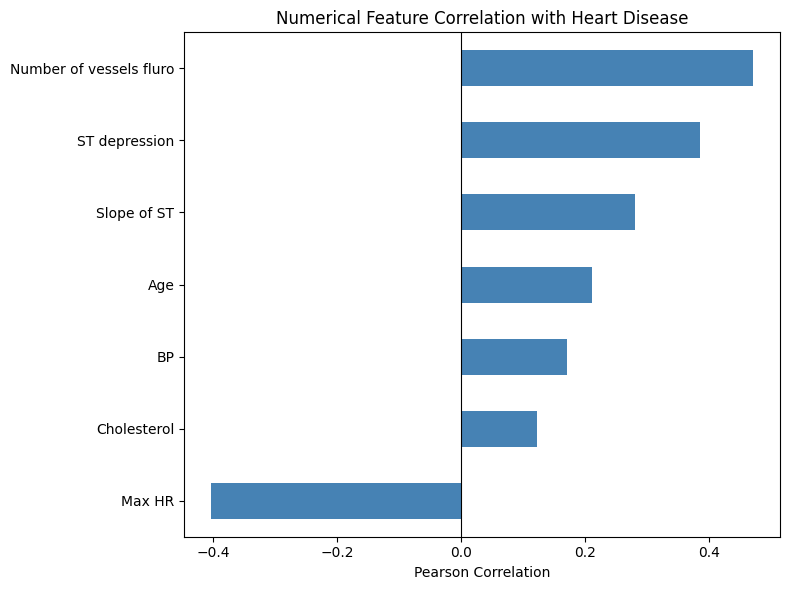

In [46]:
corr_with_target.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Numerical Feature Correlation with Heart Disease')
plt.xlabel('Pearson Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

- Most Correlated Features : Number of vessels fluro and Max HR
- Least Correlated Feature: Cholestrol

# Handling Outliers

In [47]:
quartiles = np.quantile(train_df['Cholesterol'], [0.25, 0.5, 0.75]) #Q1, Q2, Q3
# quartiles has Q1, Q2, Q3 in an array

iqr=quartiles[2]-quartiles[0] #Q3-Q1

lower_bound=quartiles[0]-1.5*iqr

upper_bound=quartiles[2]+1.5*iqr

print("our lower bound: ", lower_bound)
print("our upper bound: ", upper_bound)

train_df[train_df['Cholesterol']<lower_bound]  #nothing beneath lower bound
train_df[train_df['Cholesterol']>upper_bound]  #printing outliers


our lower bound:  117.5
our upper bound:  369.5


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,work_type_Govt_job,work_type_Private,work_type_Self-employed,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Thallium_3,Thallium_6,Thallium_7
1,67.0,1,3,115,564,0,2,160,0,1.6,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,63.0,1,4,150,407,0,2,154,0,4.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
52,65.0,1,3,140,417,1,2,157,0,0.8,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
190,56.0,1,4,134,409,0,2,150,1,1.9,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
197,62.0,1,4,140,394,0,2,157,0,1.2,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [48]:
train_df['Cholesterol'] = train_df['Cholesterol'].clip(lower=lower_bound, upper=upper_bound)

In [49]:
quartiles = np.quantile(train_df['BP'], [0.25, 0.5, 0.75]) #Q1, Q2, Q3
# quartiles has Q1, Q2, Q3 in an array

iqr=quartiles[2]-quartiles[0] #Q3-Q1

lower_bound=quartiles[0]-1.5*iqr

upper_bound=quartiles[2]+1.5*iqr

print("our lower bound: ", lower_bound)
print("our upper bound: ", upper_bound)

train_df[train_df['BP']<lower_bound]  #nothing beneath lower bound
train_df[train_df['BP']>upper_bound]  #printing outliers

our lower bound:  90.0
our upper bound:  170.0


,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,...,work_type_Govt_job,work_type_Private,work_type_Self-employed,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Thallium_3,Thallium_6,Thallium_7
58,55.0,1,4,174,249.0,0,0,143,1,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
87,59.0,0,1,178,270.0,0,2,145,0,4.2,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
110,55.0,1,4,180,327.0,0,1,117,1,3.4,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
117,56.0,1,4,200,288.0,1,2,133,1,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
153,54.0,0,2,192,283.0,0,2,195,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
168,66.0,1,4,178,228.0,1,0,165,1,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
174,64.0,1,4,180,325.0,0,0,154,1,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [50]:
train_df['BP'] = train_df['BP'].clip(lower=lower_bound, upper=upper_bound)
test_df['BP']  = test_df['BP'].clip(lower=lower_bound, upper=upper_bound)

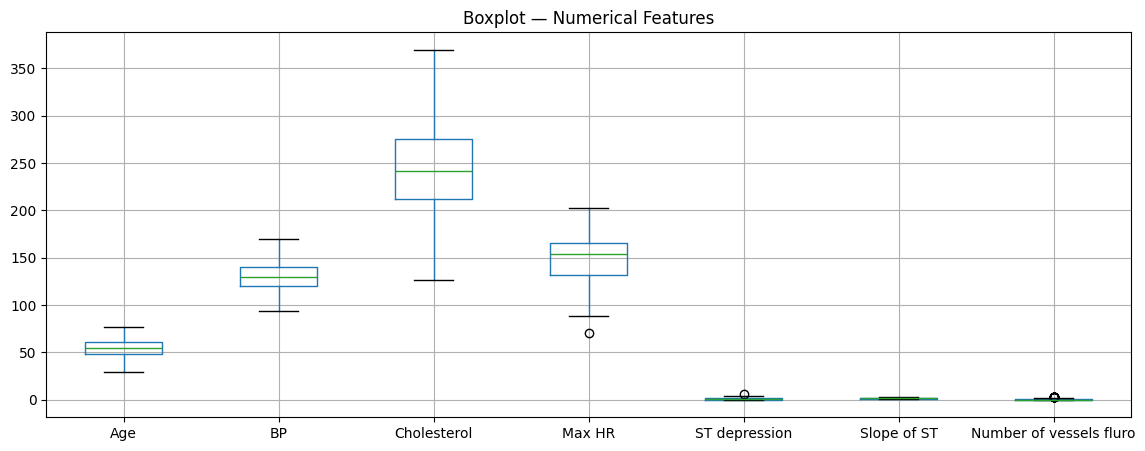

In [51]:
train_df[numerical_cols].boxplot(figsize=(14, 5))
plt.title("Boxplot — Numerical Features")
plt.show()

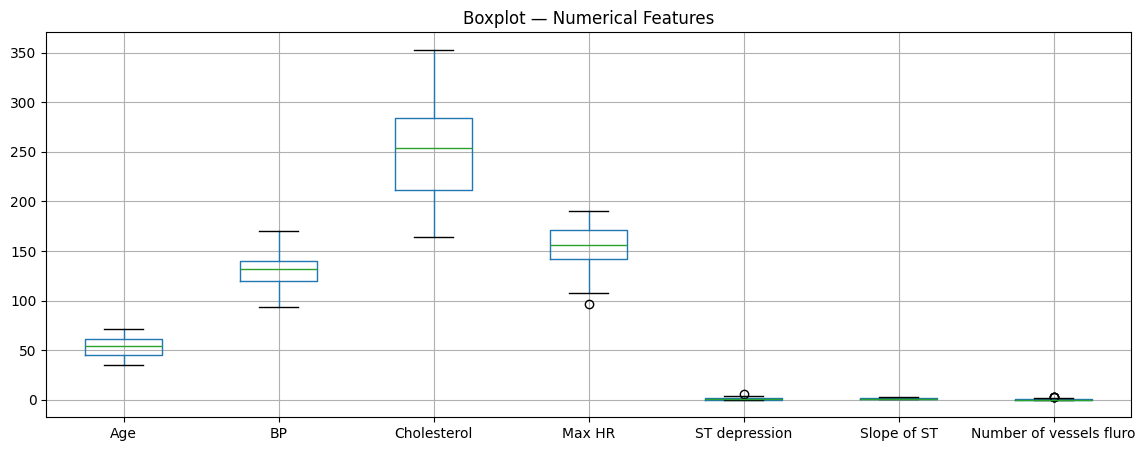

In [52]:
test_df[numerical_cols].boxplot(figsize=(14, 5))
plt.title("Boxplot — Numerical Features")
plt.show()

# Scaling Numerical Featurers

In [53]:


scaler = MinMaxScaler()


train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols]  = scaler.transform(test_df[numerical_cols])

# Split Data

In [54]:
X_train = train_df.drop(columns=['Heart Disease'])
y_train = train_df['Heart Disease']

X_test = test_df.drop(columns=['Heart Disease'])
y_test = test_df['Heart Disease']

In [55]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (223, 22)
X_test shape: (53, 22)


# Models Training and Selection

## GridSearchCV on KNN

In [56]:
#KNN

param_grid = {
    'n_neighbors': [7, 9, 11, 13, 15, 17, 19],
    'weights': ['uniform'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10,
    scoring='accuracy',
)
grid_search.fit(X_train, y_train)
best_knn = grid_search.best_estimator_

y_pred_train_knn = best_knn.predict(X_train)
y_pred_test_knn  = best_knn.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train_knn)
test_acc  = accuracy_score(y_test,  y_pred_test_knn)

print("Best Parameters found by GridSearch:", grid_search.best_params_)
print(f"Final Model Performance:")
print(f"- Best K: {grid_search.best_params_['n_neighbors']}")
print(f"- Train Accuracy: {train_acc:.2%}")
print(f"- Test Accuracy: {accuracy_score(y_test, y_pred_test_knn):.2%}")

Best Parameters found by GridSearch: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Final Model Performance:
- Best K: 13
- Train Accuracy: 86.10%
- Test Accuracy: 83.02%


KNN was tested across three configurations — Euclidean, Manhattan, and distance-weighted. Test accuracy ranged from 81.1% to 83.0%. The distance-weighted version in particular hit 86% training accuracy.

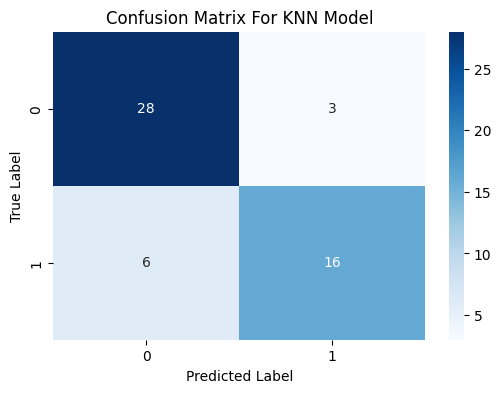

In [57]:
cm = confusion_matrix(y_test, y_pred_test_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For KNN Model')
plt.show()

## Decision Tree Base Model

In [58]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
# Decision Tree Training
y_train_pred_dt = baseline_dt.predict(X_train)
y_test_pred_dt = baseline_dt.predict(X_test)

print("Decision Tree Results:")
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt))

Decision Tree Results:

Training Accuracy: 1.0
Test Accuracy: 0.8301886792452831

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        31
           1       0.81      0.77      0.79        22

    accuracy                           0.83        53
   macro avg       0.83      0.82      0.82        53
weighted avg       0.83      0.83      0.83        53


Confusion Matrix:
[[27  4]
 [ 5 17]]


## GridSearchCV on Decision Tree

In [60]:
# Grid Search for Decision Tree


dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 8, 10],
    'class_weight': ['balanced', None],
    'ccp_alpha': [0.0, 0.005, 0.01]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred_best)
test_acc  = accuracy_score(y_test,  y_test_pred_best)

print("=== Grid Search Results ===")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("Optimized Decision Tree Results (After Grid Search)")
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred_best))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_best))

=== Grid Search Results ===
Best Parameters: {'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best Cross-Validation Score: 0.8389328063241107
Optimized Decision Tree Results (After Grid Search)

Training Accuracy: 0.8609865470852018
Test Accuracy: 0.8490566037735849


## Base XGBoost

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
#XGBoost Model
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

XGBoost Results:
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       0.89      0.77      0.83        22

    accuracy                           0.87        53
   macro avg       0.87      0.85      0.86        53
weighted avg       0.87      0.87      0.87        53

Confusion Matrix:
[[29  2]
 [ 5 17]]
Accuracy:
0.8679245283018868


## GridSearchCV on XGBoost

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.8114141414141415

Train Accuracy: 0.9237668161434978
Test Accuracy: 0.8867924528301887
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        31
           1       0.94      0.77      0.85        22

    accuracy                           0.89        53
   macro avg       0.90      0.87      0.88        53
weighted avg       0.89      0.89      0.88        53



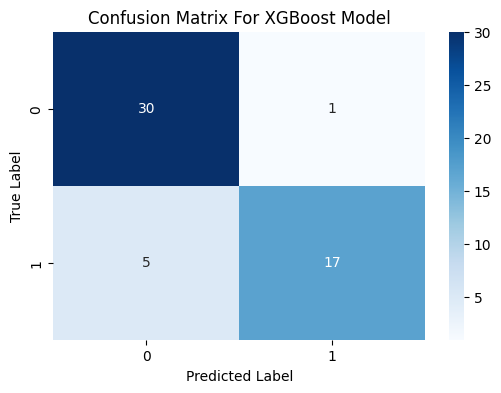

In [63]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_test_xgb = best_xgb.predict(X_test)

print("\nTrain Accuracy:", accuracy_score(y_train, y_pred_train_xgb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_xgb))
print(classification_report(y_test, y_pred_test_xgb))

cm = confusion_matrix(y_test, y_pred_test_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For XGBoost Model')
plt.show()

In [64]:
y_prob = best_xgb.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.45, 0.40, 0.35]
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    print(f"Threshold {t} → Recall(1): {report['1']['recall']:.2f}  "
          f"Precision(1): {report['1']['precision']:.2f}  "
          f"Accuracy: {report['accuracy']:.2f}")

Threshold 0.5 → Recall(1): 0.77  Precision(1): 0.94  Accuracy: 0.89
Threshold 0.45 → Recall(1): 0.77  Precision(1): 0.94  Accuracy: 0.89
Threshold 0.4 → Recall(1): 0.82  Precision(1): 0.90  Accuracy: 0.89
Threshold 0.35 → Recall(1): 0.82  Precision(1): 0.82  Accuracy: 0.85


              precision    recall  f1-score   support

           0       0.88      0.94      0.91        31
           1       0.90      0.82      0.86        22

    accuracy                           0.89        53
   macro avg       0.89      0.88      0.88        53
weighted avg       0.89      0.89      0.89        53



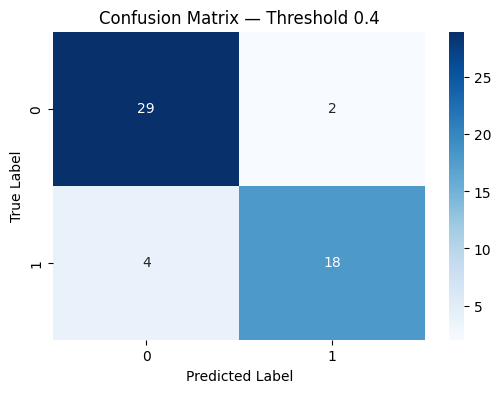

In [65]:
best_threshold = 0.40
y_pred_final = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — Threshold {best_threshold}')
plt.show()

## Base SVM

In [66]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = SVC(C = 1, kernel = "linear", random_state=42)
svm_model.fit(X_train, y_train)

y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)

In [67]:
#SVM model
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_svm))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_svm))

print(classification_report(y_test, y_pred_test_svm))

Train Accuracy: 0.852017937219731
Test Accuracy: 0.8490566037735849
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        31
           1       0.85      0.77      0.81        22

    accuracy                           0.85        53
   macro avg       0.85      0.84      0.84        53
weighted avg       0.85      0.85      0.85        53



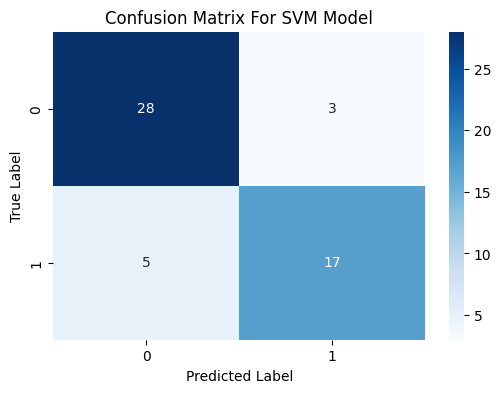

In [68]:
cm = confusion_matrix(y_test, y_pred_test_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For SVM Model')
plt.show()

SVM with a linear kernel achieved a test accuracy of 84.9% and a macro F1 of 0.84, with a near-zero train-test gap of 0.3%, indicating strong generalization with no overfitting.

## GridSearch on SVM

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'C': 5, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score: 0.8355282034702887

Train Accuracy: 0.8923766816143498
Test Accuracy: 0.8301886792452831
              precision    recall  f1-score   support

           0       0.84      0.87      0.86        31
           1       0.81      0.77      0.79        22

    accuracy                           0.83        53
   macro avg       0.83      0.82      0.82        53
weighted avg       0.83      0.83      0.83        53



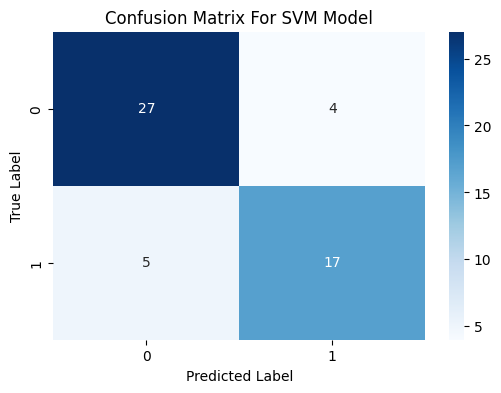

In [69]:
param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1
)

grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_svm = grid_search.best_estimator_
y_pred_train_GridSVM = best_svm.predict(X_train)
y_pred_test_GridSVM = best_svm.predict(X_test)

print("\nTrain Accuracy:", accuracy_score(y_train, y_pred_train_GridSVM))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_GridSVM))
print(classification_report(y_test, y_pred_test_GridSVM))

cm = confusion_matrix(y_test, y_pred_test_GridSVM)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For SVM Model')
plt.show()

## Base Logistic Regression

In [70]:
log_model = LogisticRegression(
    C=10,
    solver='lbfgs',
    max_iter=1000
)

log_model.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=1000)

Train Accuracy: 0.852017937219731
Test Accuracy: 0.8679245283018868
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       0.89      0.77      0.83        22

    accuracy                           0.87        53
   macro avg       0.87      0.85      0.86        53
weighted avg       0.87      0.87      0.87        53



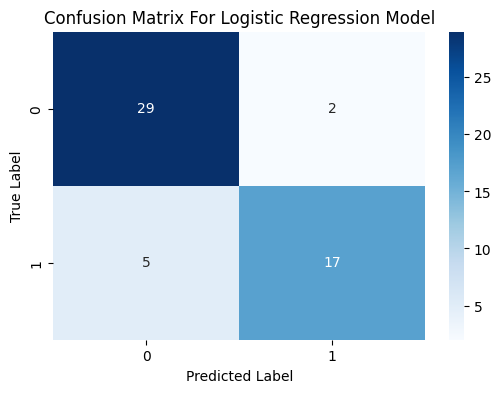

In [71]:
#Logistic Regression Model

y_train_pred = log_model.predict(X_train)
y_test_pred = log_model.predict(X_test)

print("Train Accuracy:",
      accuracy_score(y_train, y_train_pred))
print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For Logistic Regression Model')
plt.show()

## GridSearchCV on Logistic Regression

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.8230232100011452

Train Accuracy: 0.852017937219731
Test Accuracy: 0.8490566037735849

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        31
           1       0.85      0.77      0.81        22

    accuracy                           0.85        53
   macro avg       0.85      0.84      0.84        53
weighted avg       0.85      0.85      0.85        53



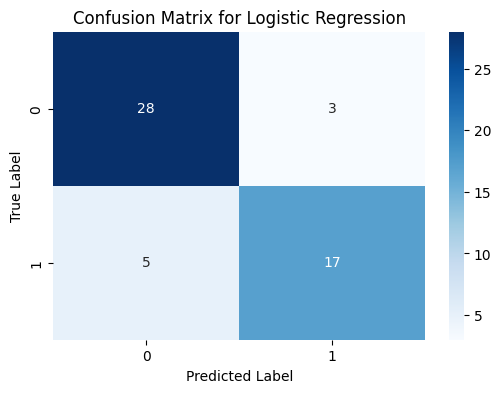

In [72]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 3000]
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_log_model = grid_search.best_estimator_

y_pred_train_log = best_log_model.predict(X_train)
y_pred_test_log = best_log_model.predict(X_test)

print("\nTrain Accuracy:", accuracy_score(y_train, y_pred_train_log))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_log))

cm = confusion_matrix(y_test, y_pred_test_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')

plt.show()

## Base Random Forest

In [73]:
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
y_pred_train_baseline = rf_baseline.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_baseline))
print("Test Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))

Train Accuracy: 1.0
Test Accuracy: 0.8679245283018868
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       0.89      0.77      0.83        22

    accuracy                           0.87        53
   macro avg       0.87      0.85      0.86        53
weighted avg       0.87      0.87      0.87        53



## GridSearchCV on Random Forest

In [74]:

rf= RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 75, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 7, 9, 11],
    'min_samples_split': [ 5,7,9, 10],
    'min_samples_leaf': [ 4, 6,8,10],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)


Fitting 5 folds for each of 768 candidates, totalling 3840 fits


In [75]:
print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 75}
Train Accuracy: 0.9013452914798207
Test Accuracy: 0.8679245283018868


              precision    recall  f1-score   support

           0       0.85      0.94      0.89        31
           1       0.89      0.77      0.83        22

    accuracy                           0.87        53
   macro avg       0.87      0.85      0.86        53
weighted avg       0.87      0.87      0.87        53



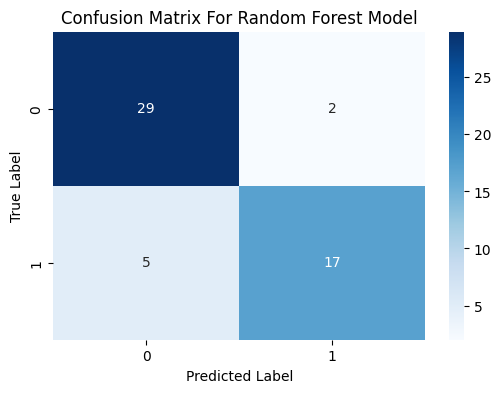

In [76]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix For Random Forest Model')
plt.show()